<a href="https://colab.research.google.com/github/waj-ha/child-safety-fars-analysis/blob/main/notebooks/260609_FAR_2024_child-safety_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Relevant Columns:

**`STATE`**: Compare the US states.

**`ST_CASE`**: Identify the crash case and Unique ID.

**`PER_NO`**: Identify the each person with Unique ID.

**`VEH_NO`**: Identify the vehicle with Unique ID.

**`AGE`**: Identify the age groups and risk difference.

**`SEX`**: Compare outcomes in males and females.

**`PER_TYP`**: Identify the type of perssenger. Occupant/Pedestrain.

**`REST_USE`**: Compare the impact of use of restaint Systems and seatbelts.

**`SEAT_POS`**: Analyses seat position Effects.

**`INJ_SEV`**: Measure Crash outcomes.

**`BODY_TYP`**: Compare Vehicle types.

**`HOUR`**: Study Time of the day patterns.

**`DAY`**: Study patterns in the day.

**`RUR_URB`**: Compare rural or urban crash characteristics.




# Data Analysis Enssential Tools and Libraries:
These libraries are essential tools for most data science workflows:

*   **NumPy**: Fundamental package for numerical computation, especially with arrays and matrices.
*   **Pandas**: Provides high-performance, easy-to-use data structures and data analysis tools (DataFrames).
*   **Matplotlib**: A comprehensive library for creating static, animated, and interactive visualizations.
*   **Seaborn**: Built on Matplotlib, it provides a high-level interface for drawing attractive and informative statistical graphics.
*   **Statsmodels**: Provides classes and functions for the estimation of many different statistical models, as well as for conducting statistical tests and statistical data exploration.

The `!pip install` command is used to install Python packages. The `!` at the beginning tells Colab to run the command as a shell command. In this example, `numpy` is the name of the package to be installed.

In [93]:
common_data_science_libraries = [
    "numpy",        # Numerical operations
    "pandas",       # Data manipulation and analysis
    "matplotlib",   # Basic plotting
    "seaborn",      # Enhanced statistical data visualization
    "statsmodels",  # Statistical modeling
    "requests",     # HTTP requests for web data
]

# Install all listed libraries
!pip install {" ".join(common_data_science_libraries)}



In [94]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt # Import pyplot for plotting functions
import seaborn as sns
import sklearn
import tensorflow as tf

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}") # Access version from the main module
print(f"Seaborn version: {sns.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"TensorFlow version: {tf.__version__}")

# You can add simple verification tests here if needed, for example:
# print(np.array([1, 2, 3]) + np.array([4, 5, 6]))
# print(pd.DataFrame({'A': [1, 2], 'B': [3, 4]}))

NumPy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1
TensorFlow version: 2.20.0


# Dataset Import
Raw data is placed at Github;

https://github.com/waj-ha/child-safety-fars-analysis.git

and accessed, and imported via Pandas Libraries. The files sizes are more than 100MB. So, these are

In [95]:
import pandas as pd
url_accident = 'https://media.githubusercontent.com/media/waj-ha/child-safety-fars-analysis/refs/heads/main/data/raw/accident.csv'
df_raw_accident = pd.read_csv(url_accident,encoding='unicode_escape', dtype=str, low_memory=False)
url_person = 'https://media.githubusercontent.com/media/waj-ha/child-safety-fars-analysis/refs/heads/main/data/raw/person.csv'
df_raw_person = pd.read_csv(url_person,encoding='unicode_escape', dtype=str, low_memory=False)
#url_vehicle = 'https://media.githubusercontent.com/media/waj-ha/child-safety-fars-analysis/refs/heads/main/data/raw/vehicle.csv'
#df_raw_vehicle = pd.read_csv(url_vehicle,encoding='unicode_escape', dtype=str, low_memory=False)

---



# EDA Overview

In [96]:
def dataset_overview(df, dataset_name):
    print("*****************")
    print(f"{dataset_name} Dataset:")
    print("*****************")
    print("\nShape:", df.shape)
    print("\nCount:")
    print(df.nunique().sort_values(ascending=False))
    print("\nData Types:")
    print(df.dtypes.value_counts(ascending=False))
    print("\nDuplicates:", df.duplicated().sum())
    print(f"\nMissing Values Count:")
    missing_values = (df.isnull().sum().sort_values(ascending=False))
    non_zero_missing_values = missing_values[missing_values > 0]
    print(non_zero_missing_values)
    print(f"\nMissing Values Percentage:")
    missing_percentage = round(df.isnull().sum() * 100 / len(df), 2).sort_values(ascending=False)
    non_zero_missing_percentage = missing_percentage[missing_percentage > 0]
    print(non_zero_missing_percentage)
    print("\n---------------------------------------------------\n")

dataset_overview(df_raw_person, "Person")
dataset_overview(df_raw_accident, "Accident")
#dataset_overview(df_raw_vehicle, "Vehicle")


*****************
Person Dataset:
*****************

Shape: (88326, 126)

Count:
ST_CASE          36297
VPICMODEL         2381
VPICMODELNAME     2325
DEATH_TM          1457
DEATH_TMNAME      1457
                 ...  
EXTRICATNAME         3
FIRE_EXPNAME         2
FIRE_EXP             2
SCH_BUSNAME          2
SCH_BUS              2
Length: 126, dtype: int64

Data Types:
object    126
Name: count, dtype: int64

Duplicates: 0

Missing Values Count:
VPICMAKE             9020
MOD_YEAR             9020
VPICMODEL            9020
VPICMAKENAME         9020
MOD_YEARNAME         9020
FIRE_EXPNAME         9020
FIRE_EXP             9020
IMPACT1NAME          9020
IMPACT1              9020
ROLLOVERNAME         9020
ROLLOVER             9020
EMER_USENAME         9020
EMER_USE             9020
SPEC_USENAME         9020
SPEC_USE             9020
TOW_VEHNAME          9020
TOW_VEH              9020
GVWR_TONAME          9020
GVWR_TO              9020
GVWR_FROMNAME        9020
GVWR_FROM            9020
ICF



___



## Primary Key Indentification

## `ST_CASE`:Consecutive Number (Primary Key)

This data element is the unique case number assigned to each crash. It appears on each data file
and is used to merge information from the data files together.

This data element is stored as a **numeric data element of six characters**;
the first two characters are the State code,
and the next four characters are case number with leading zeros if necessary.

[Fatality Analysis Reporting System Analytical User’s Manual, 1975-2024](https://github.com/waj-ha/child-safety-fars-analysis/blob/6c3be83f1700cb93c8d3a495211a92ccfd7aea08/references/Fatality%20Analysis%20Reporting%20System%20Analytical%20User%E2%80%99s%20Manual%2C%201975-2024.pdf)

(Page#31)

In [97]:
df_person_case = df_raw_person.copy()
df_person_case['ST_CASE'].unique(), df_person_case['ST_CASE'].duplicated().sum(), df_person_case['ST_CASE'].isnull().sum(), df_person_case['ST_CASE'].dtypes

(array(['10001', '10002', '10003', ..., '560100', '560101', '560102'],
       dtype=object),
 np.int64(52029),
 np.int64(0),
 dtype('O'))

In [98]:
counts = df_person_case['ST_CASE'].value_counts()
counts[counts > 5]

,count
ST_CASE,
480776,59
121482,46
280403,38
260959,35
481200,32
...,...
400037,6
410332,6
550331,6


In [99]:
df_person_case[df_person_case['ST_CASE'] == '480776'].head(5)

,STATE,STATENAME,ST_CASE,VEH_NO,PER_NO,VE_FORMS,COUNTY,MONTH,MONTHNAME,DAY,...,DEVTYPE,DEVTYPENAME,DEVMOTOR,DEVMOTORNAME,LOCATION,LOCATIONNAME,WORK_INJ,WORK_INJNAME,HISPANIC,HISPANICNAME
74340,48,Texas,480776,1,1,4,21,3,March,22,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,8,Not Applicable (not a fatality),0,Not A Fatality (not Applicable)
74341,48,Texas,480776,2,1,4,21,3,March,22,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,8,Not Applicable (not a fatality),0,Not A Fatality (not Applicable)
74342,48,Texas,480776,2,2,4,21,3,March,22,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,0,No,1,Mexican
74343,48,Texas,480776,2,3,4,21,3,March,22,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,8,Not Applicable (not a fatality),0,Not A Fatality (not Applicable)
74344,48,Texas,480776,2,4,4,21,3,March,22,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,8,Not Applicable (not a fatality),0,Not A Fatality (not Applicable)


##`PER_NO`:Person Number (Primary Key)

This data element is the consecutive number assigned to each person in the case (i.e., each
occupant, pedestrian, or non-motorists involved in the crash). This data element appears on each
person level data file and is used in conjunction with the ST_CASE data element (and sometimes
the VEH_NO data element) to merge information from person level data files.

[Fatality Analysis Reporting System Analytical User’s Manual, 1975-2024](https://github.com/waj-ha/child-safety-fars-analysis/blob/6c3be83f1700cb93c8d3a495211a92ccfd7aea08/references/Fatality%20Analysis%20Reporting%20System%20Analytical%20User%E2%80%99s%20Manual%2C%201975-2024.pdf)

(Page#33)

In [100]:
person_case_no = df_raw_person.copy()
person_case_no['PER_NO'].unique(), person_case_no['PER_NO'].duplicated().sum(), person_case_no['PER_NO'].isnull().sum(), person_case_no['PER_NO'].dtypes

(array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
        '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
        '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34',
        '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45',
        '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56'],
       dtype=object),
 np.int64(88270),
 np.int64(0),
 dtype('O'))

In [101]:
counts = person_case_no['PER_NO'].value_counts()
counts[counts > 0]

,count
PER_NO,
1,64493
2,15107
3,4844
4,2200
5,887
6,311
7,126
8,71
9,41


In [102]:
person_case_no[person_case_no['PER_NO'] == '56'].head(5)

,STATE,STATENAME,ST_CASE,VEH_NO,PER_NO,VE_FORMS,COUNTY,MONTH,MONTHNAME,DAY,...,DEVTYPE,DEVTYPENAME,DEVMOTOR,DEVMOTORNAME,LOCATION,LOCATIONNAME,WORK_INJ,WORK_INJNAME,HISPANIC,HISPANICNAME
74396,48,Texas,480776,2,56,4,21,3,March,22,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,8,Not Applicable (not a fatality),0,Not A Fatality (not Applicable)


## `VEH_NO`:Vehicle Number (Primary Key)

This data element is the consecutive number assigned to each person in the case (i.e., each
occupant, pedestrian, or non-motorists involved in the crash). This data element appears on each
person level data file and is used in conjunction with the ST_CASE data element (and sometimes
the VEH_NO data element) to merge information from person level data files.

[Fatality Analysis Reporting System Analytical User’s Manual, 1975-2024](https://github.com/waj-ha/child-safety-fars-analysis/blob/6c3be83f1700cb93c8d3a495211a92ccfd7aea08/references/Fatality%20Analysis%20Reporting%20System%20Analytical%20User%E2%80%99s%20Manual%2C%201975-2024.pdf)

(Page#32)

In [103]:
person_case_no = df_raw_person.copy()
person_case_no['VEH_NO'].unique(), person_case_no['VEH_NO'].duplicated().sum(), person_case_no['VEH_NO'].isnull().sum(), person_case_no['VEH_NO'].dtypes

(array(['1', '0', '3', '2', '4', '5', '6', '7', '8', '9', '10', '11', '12',
        '13', '14', '15'], dtype=object),
 np.int64(88310),
 np.int64(0),
 dtype('O'))

In [104]:
counts = person_case_no['VEH_NO'].value_counts()
counts[counts > 0]

,count
VEH_NO,
1,49660
2,23865
0,9020
3,4039
4,1067
5,382
6,137
7,63
8,33


In [105]:
person_case_no[person_case_no['VEH_NO'] == '13'].head(5)

,STATE,STATENAME,ST_CASE,VEH_NO,PER_NO,VE_FORMS,COUNTY,MONTH,MONTHNAME,DAY,...,DEVTYPE,DEVTYPENAME,DEVMOTOR,DEVMOTORNAME,LOCATION,LOCATIONNAME,WORK_INJ,WORK_INJNAME,HISPANIC,HISPANICNAME
43607,26,Michigan,260959,13,1,15,65,11,November,2,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,0,No,7,Non-Hispanic
43608,26,Michigan,260959,13,2,15,65,11,November,2,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,0,No,7,Non-Hispanic
43609,26,Michigan,260959,13,3,15,65,11,November,2,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,0,No,7,Non-Hispanic
65149,42,Pennsylvania,420224,13,1,13,133,4,April,16,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,8,Not Applicable (not a fatality),0,Not A Fatality (not Applicable)


In [106]:
person_case_no[['ST_CASE','PER_NO','VEH_NO']].duplicated().sum(),
person_case_no[['ST_CASE','PER_NO','VEH_NO']].isnull().sum(), person_case_no[['ST_CASE','PER_NO','VEH_NO']].dtypes

(ST_CASE    0
 PER_NO     0
 VEH_NO     0
 dtype: int64,
 ST_CASE    object
 PER_NO     object
 VEH_NO     object
 dtype: object)

In [107]:
print(person_case_no.shape)
person_case_no.head(5)

(88326, 126)


,STATE,STATENAME,ST_CASE,VEH_NO,PER_NO,VE_FORMS,COUNTY,MONTH,MONTHNAME,DAY,...,DEVTYPE,DEVTYPENAME,DEVMOTOR,DEVMOTORNAME,LOCATION,LOCATIONNAME,WORK_INJ,WORK_INJNAME,HISPANIC,HISPANICNAME
0,1,Alabama,10001,1,1,1,125,1,January,1,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,0,No,7,Non-Hispanic
1,1,Alabama,10002,1,1,1,73,1,January,2,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,0,No,7,Non-Hispanic
2,1,Alabama,10003,0,1,1,3,1,January,2,...,0,Not Applicable,0,Not Applicable,11,"Not at Intersection - On Roadway, Not in Marke...",0,No,7,Non-Hispanic
3,1,Alabama,10003,1,1,1,3,1,January,2,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,8,Not Applicable (not a fatality),0,Not A Fatality (not Applicable)
4,1,Alabama,10003,1,2,1,3,1,January,2,...,96,Occupant of a Motor Vehicle,8,Occupant of a Motor Vehicle,0,Occupant of a Motor Vehicle,8,Not Applicable (not a fatality),0,Not A Fatality (not Applicable)


In [108]:
def primary_key_check(df):
  duplicates = df.duplicated().sum()
  missing_values = df.isnull().sum().sum()
  data_types = df.dtypes.value_counts()
  print(f"Duplicates: {duplicates}")
  print(f"Missing Values: {missing_values}")

  if duplicates == 0 & missing_values == 0:
    print("Primay Key Check:PASSED")
  else:
    print("Primary Key Check: FAILED")

primary_key_check(person_case_no[['ST_CASE','PER_NO','VEH_NO']])

Duplicates: 0
Missing Values: 0
Primay Key Check:PASSED




---



# Data Cleanup

## `AGE`
This data element identifies the person’s age in years on the date of the crash.
According to reference manual, the valid age is between 0-120.

[Fatality Analysis Reporting System Analytical User’s Manual, 1975-2024](https://github.com/waj-ha/child-safety-fars-analysis/blob/6c3be83f1700cb93c8d3a495211a92ccfd7aea08/references/Fatality%20Analysis%20Reporting%20System%20Analytical%20User%E2%80%99s%20Manual%2C%201975-2024.pdf)

From FARS reference manual, we know the outliers are defined with special codes. For **`AGE`** these code are,

*   `998` = Unknow
*   `999` = Not Reported

To get the real age distribution, rows with these codes should be removed.
(Page#296)


In [109]:
df_raw_person_age = df_raw_person.copy()
df_raw_person_age['AGE'].unique(),df_raw_person_age.duplicated().sum(), df_raw_person_age.shape, df_raw_person_age['AGE'].isna().sum(), df_raw_person_age['AGE'].dtypes

(array(['50', '42', '47', '23', '19', '60', '66', '31', '28', '25', '48',
        '999', '45', '29', '53', '15', '62', '16', '998', '22', '24', '46',
        '65', '39', '40', '59', '32', '70', '52', '54', '68', '33', '58',
        '27', '44', '37', '71', '34', '35', '8', '11', '30', '57', '55',
        '36', '61', '17', '49', '63', '21', '74', '72', '56', '20', '77',
        '38', '78', '18', '73', '43', '14', '75', '41', '67', '82', '87',
        '51', '69', '26', '79', '85', '7', '13', '4', '76', '90', '3',
        '12', '5', '6', '10', '81', '89', '64', '80', '2', '84', '83', '1',
        '9', '86', '0', '88', '94', '93', '91', '95', '97', '96', '92',
        '101', '98', '99', '100'], dtype=object),
 np.int64(0),
 (88326, 126),
 np.int64(0),
 dtype('O'))

In [110]:
df_person_age = df_raw_person.copy()
df_person_age = df_person_age[df_person_age['AGE'] != '998']
df_person_age = df_person_age[df_person_age['AGE'] != '999']
df_person_age['AGE'] = pd.to_numeric(df_person_age['AGE'])
df_person_age.shape
df_person_age['AGE'].unique()


array([ 50,  42,  47,  23,  19,  60,  66,  31,  28,  25,  48,  45,  29,
        53,  15,  62,  16,  22,  24,  46,  65,  39,  40,  59,  32,  70,
        52,  54,  68,  33,  58,  27,  44,  37,  71,  34,  35,   8,  11,
        30,  57,  55,  36,  61,  17,  49,  63,  21,  74,  72,  56,  20,
        77,  38,  78,  18,  73,  43,  14,  75,  41,  67,  82,  87,  51,
        69,  26,  79,  85,   7,  13,   4,  76,  90,   3,  12,   5,   6,
        10,  81,  89,  64,  80,   2,  84,  83,   1,   9,  86,   0,  88,
        94,  93,  91,  95,  97,  96,  92, 101,  98,  99, 100])

## `SEX`
This data element identifies the sex of this person involved in the crash.

[Fatality Analysis Reporting System Analytical User’s Manual, 1975-2024](https://github.com/waj-ha/child-safety-fars-analysis/blob/6c3be83f1700cb93c8d3a495211a92ccfd7aea08/references/Fatality%20Analysis%20Reporting%20System%20Analytical%20User%E2%80%99s%20Manual%2C%201975-2024.pdf)

From FARS reference manual, we know the outliers are defined with special codes. For **`SEX`** these code are,

*   `8` = Not Reported
*   `9` = Reported as Unknow

To get the real age distribution, rows with these codes should be removed.

(Page#294)

In [111]:
df_raw_person_sex = df_person_age.copy()
df_raw_person_sex['SEX'].unique(),df_raw_person_sex.duplicated().sum(), df_raw_person_sex.shape, df_raw_person_sex['SEX'].isna().sum(), df_raw_person_sex['SEX'].dtypes

(array(['1', '2', '8', '9'], dtype=object),
 np.int64(0),
 (86073, 126),
 np.int64(0),
 dtype('O'))

In [112]:
df_raw_person_sex[['ST_CASE', 'PER_NO', 'SEX', 'SEXNAME']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 86073 entries, 0 to 88325
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   ST_CASE  86073 non-null  object
 1   PER_NO   86073 non-null  object
 2   SEX      86073 non-null  object
 3   SEXNAME  86073 non-null  object
dtypes: object(4)
memory usage: 3.3+ MB


In [113]:
df_raw_person_sex_unknow = df_raw_person_sex[df_raw_person_sex['SEX'].isin(['8', '9'])]
df_raw_person_sex_unknow.shape

(191, 126)

In [114]:
df_person_sex = df_raw_person_sex[
    (df_raw_person_sex['SEX'] != '8') &
    (df_raw_person_sex['SEX'] != '9')
]

In [115]:
df_person_sex['SEX'].unique(),df_person_sex.duplicated().sum(), df_person_sex.shape, df_person_sex['SEX'].isna().sum(), df_person_sex['SEX'].dtypes

(array(['1', '2'], dtype=object),
 np.int64(0),
 (85882, 126),
 np.int64(0),
 dtype('O'))

In [116]:
df_person_sex['SEX'].value_counts().sum() + df_raw_person_sex_unknow['SEX'].value_counts().sum()

np.int64(86073)

In [117]:
df_person_sex[['SEX','SEXNAME']].value_counts()

,,count
SEX,SEXNAME,
1,Male,58081
2,Female,27801


## `PER_TYP`
This data element describes the role of this person or non-motorist at the time they became
involved in the crash.`

From FARS reference manual, we know the outliers are defined with special codes. For **`PER_TYP`** these code are,

*   `9` = Unknown Occupant Type in a Motor Vehicle In-Transport
*   `10` = Person In/On a Building

To get the real distribution, rows with these codes should be removed.

Page# 298

In [118]:
df_raw_person_per_typ = df_person_sex.copy()
df_raw_person_per_typ['PER_TYP'].unique(),df_raw_person_per_typ.duplicated().sum(), df_raw_person_per_typ.shape, df_raw_person_per_typ['PER_TYP'].isna().sum(), df_raw_person_per_typ['PER_TYP'].dtypes

(array(['1', '5', '2', '3', '6', '8', '7', '9', '10', '4'], dtype=object),
 np.int64(0),
 (85882, 126),
 np.int64(0),
 dtype('O'))

In [119]:
df_raw_person_per_typ[['PER_TYP', 'PER_TYPNAME']].value_counts()

,,count
PER_TYP,PER_TYPNAME,
1,Driver of a Motor Vehicle In-Transport,53951
2,Passenger of a Motor Vehicle In-Transport,22601
5,Pedestrian,7380
6,Bicyclist,1081
3,Occupant of a Motor Vehicle Not In- Transport,411
8,Person on a Personal Conveyance,275
9,Unknown Occupant Type in a Motor Vehicle In- Transport,77
4,Occupant of a Non-Motor Vehicle Transport Device,47
7,Other Pedalcyclist,30


In [120]:
df_person_per_typ = df_raw_person_per_typ[
    (df_raw_person_per_typ['PER_TYP'] != '9') &
    (df_raw_person_per_typ['PER_TYP'] != '10')
    ]

In [121]:
df_person_per_typ['PER_TYP'].unique(),df_person_per_typ.duplicated().sum(), df_person_per_typ.shape, df_person_per_typ['PER_TYP'].isna().sum(), df_person_per_typ['PER_TYP'].dtypes

(array(['1', '5', '2', '3', '6', '8', '7', '4'], dtype=object),
 np.int64(0),
 (85776, 126),
 np.int64(0),
 dtype('O'))

In [122]:
df_person_per_typ[['PER_TYP','PER_TYPNAME']].value_counts()

,,count
PER_TYP,PER_TYPNAME,
1,Driver of a Motor Vehicle In-Transport,53951
2,Passenger of a Motor Vehicle In-Transport,22601
5,Pedestrian,7380
6,Bicyclist,1081
3,Occupant of a Motor Vehicle Not In- Transport,411
8,Person on a Personal Conveyance,275
4,Occupant of a Non-Motor Vehicle Transport Device,47
7,Other Pedalcyclist,30


## `INJ_SEV` and FATAL
This data element describes the severity of the injury to this person in the crash using the
KABCO scale.

From FARS reference manual, we know the outliers are defined with special codes. For INJ_SEV these code are,

`9` = Unknown/Not Reported

To get the real distribution, rows with these codes should be removed.

Page#300

In [123]:
df_raw_person_injury = df_person_per_typ.copy()
df_raw_person_injury['INJ_SEV'].unique(),df_raw_person_injury.duplicated().sum(), df_raw_person_injury.shape, df_raw_person_injury['INJ_SEV'].isna().sum(), df_raw_person_injury['INJ_SEV'].dtypes

(array(['4', '0', '1', '3', '2', '9', '5', '6'], dtype=object),
 np.int64(0),
 (85776, 126),
 np.int64(0),
 dtype('O'))

In [124]:
df_raw_person_injury[['INJ_SEV', 'INJ_SEVNAME']].value_counts()

,,count
INJ_SEV,INJ_SEVNAME,
4,Fatal Injury (K),38946
0,No Apparent Injury (O),22569
2,Suspected Minor Injury (B),9175
3,Suspected Serious Injury (A),8774
1,Possible Injury (C),5790
9,Unknown/Not Reported,343
5,"Injured, Severity Unknown",176
6,Died Prior to Crash*,3


In [125]:
df_person_injury = df_raw_person_injury[
    (df_raw_person_injury['INJ_SEV'] != '9' )
    ]

In [126]:
df_person_injury[['INJ_SEV','INJ_SEVNAME']].value_counts()

,,count
INJ_SEV,INJ_SEVNAME,
4,Fatal Injury (K),38946
0,No Apparent Injury (O),22569
2,Suspected Minor Injury (B),9175
3,Suspected Serious Injury (A),8774
1,Possible Injury (C),5790
5,"Injured, Severity Unknown",176
6,Died Prior to Crash*,3


In [127]:
df_person_fatality= df_person_injury[
    (df_person_injury['INJ_SEV'] == '4') +
    (df_person_injury['INJ_SEV'] == '6')]

In [128]:
df_person_fatality[['INJ_SEV','INJ_SEVNAME']].value_counts(), df_person_fatality[['INJ_SEV','INJ_SEVNAME']].value_counts().sum()

(INJ_SEV  INJ_SEVNAME         
 4        Fatal Injury (K)        38946
 6        Died Prior to Crash*        3
 Name: count, dtype: int64,
 np.int64(38949))

In [129]:
df_person_injury.shape , df_person_fatality.shape

((85433, 126), (38949, 126))

## `REST_USE`
This data element records the restraint equipment in use by this occupant at the time of the crash.

From FARS reference manual, we know the outliers are defined with special codes. For REST_USE these code are,

`99` = Unknown/Reported as Unknown (Since 2018)

`98` = Not Reported

`97` = Other

To get the real distribution, rows with these codes should be removed.

Page#304

In [130]:
df_raw_person_rest_use = df_person_injury.copy()
df_raw_person_rest_use['REST_USE'].unique(),df_raw_person_rest_use.duplicated().sum(), df_raw_person_rest_use.shape, df_raw_person_rest_use['REST_USE'].isna().sum(), df_raw_person_rest_use['REST_USE'].dtypes

(array(['3', '20', '96', '99', '10', '2', '98', '11', '1', '12', '8', '4',
        '97', '6'], dtype=object),
 np.int64(0),
 (85433, 126),
 np.int64(0),
 dtype('O'))

In [131]:
df_raw_person_rest_use[['REST_USE', 'REST_USENAME']].value_counts()

,,count
REST_USE,REST_USENAME,
3,Shoulder and Lap Belt Used,43760
20,None Used/Not Applicable,23529
96,Not a Motor Vehicle Occupant,8811
99,Reported as Unknown,6124
10,Child Restraint System - Forward Facing,622
4,Child Restraint Type Unknown,582
98,Not Reported,511
2,Lap Belt Only Used,444
1,Shoulder Belt Only Used,287


In [132]:
df_person_rest_use = df_raw_person_rest_use[
    (df_raw_person_rest_use['REST_USE'] != '99') &
    (df_raw_person_rest_use['REST_USE'] != '98') &
    (df_raw_person_rest_use['REST_USE'] != '97')
    ]


In [133]:
df_person_rest_use[['REST_USE','REST_USENAME']].value_counts()

,,count
REST_USE,REST_USENAME,
3,Shoulder and Lap Belt Used,43760
20,None Used/Not Applicable,23529
96,Not a Motor Vehicle Occupant,8811
10,Child Restraint System - Forward Facing,622
4,Child Restraint Type Unknown,582
2,Lap Belt Only Used,444
1,Shoulder Belt Only Used,287
11,Child Restraint System - Rear Facing,267
12,Booster Seat,230


## `SEAT_POS`

This data element identifies the location of this person in or on the vehicle.

From FARS reference manual, we know the outliers are defined with special codes. For SEAT_POS these code are,

`99` = Unknown/Reported as Unknown (Since 2018)

`98` = Not Reported

`56` = Appended to a Motor Vehicle for Motion

`55` = Riding on Vehicle Exterior

`54` = Trailing Unit

`53` = Other Passenger in Passenger or Cargo Area, Unknown Whether or Not Enclosed

`52` = Other Passenger in Unenclosed Passenger or Cargo
Area

`51` = Other Passenger in Enclosed Passenger or Cargo
Area (Since 2009)

`50` = Sleeper Section of Cab (Truck)

`49` = Fourth Seat, Unknown

`39` = Third Seat, Unknown

`29` = Second Seat, Unknown

`19` = Front Seat, Unknown

To get the real distribution, rows with these codes should be removed.

Page#301

In [134]:
df_raw_person_seat_pos = df_person_rest_use.copy()
df_raw_person_seat_pos['SEAT_POS'].unique(),df_raw_person_seat_pos.duplicated().sum(), df_raw_person_seat_pos.shape, df_raw_person_seat_pos['SEAT_POS'].isna().sum(), df_raw_person_seat_pos['SEAT_POS'].dtypes

(array(['11', '0', '13', '21', '23', '22', '12', '99', '50', '51', '98',
        '31', '33', '41', '32', '38', '28', '39', '55', '52', '29', '18',
        '54', '19', '53', '56', '43', '42', '49'], dtype=object),
 np.int64(0),
 (78761, 126),
 np.int64(0),
 dtype('O'))

In [135]:
df_raw_person_seat_pos[['SEAT_POS', 'SEAT_POSNAME']].value_counts()

,,count
SEAT_POS,SEAT_POSNAME,
11,"Front Seat, Left Side",49421
13,"Front Seat, Right Side",11026
0,Not a Motor Vehicle Occupant,8811
23,"Second Seat, Right Side",3360
21,"Second Seat, Left Side",3228
22,"Second Seat, Middle",897
51,Other Passenger in enclosed passenger or cargo area,483
99,Reported as Unknown,267
31,"Third Seat, Left Side",202


In [136]:
codes_to_exclude_numeric = [str(i) for i in range(50, 100)]
additional_codes_to_exclude = ['19', '29', '39', '49']

# Combine all codes to exclude into a single list
all_codes_to_exclude = codes_to_exclude_numeric + additional_codes_to_exclude

df_person_seat_pos = df_raw_person_seat_pos[
    ~df_raw_person_seat_pos['SEAT_POS'].isin(all_codes_to_exclude)
    ]

In [137]:
df_person_seat_pos[['SEAT_POS','SEAT_POSNAME']].value_counts()

,,count
SEAT_POS,SEAT_POSNAME,
11,"Front Seat, Left Side",49421
13,"Front Seat, Right Side",11026
0,Not a Motor Vehicle Occupant,8811
23,"Second Seat, Right Side",3360
21,"Second Seat, Left Side",3228
22,"Second Seat, Middle",897
31,"Third Seat, Left Side",202
33,"Third Seat, Right Side",195
12,"Front Seat, Middle",142


## `BODY_TYP`

This data element identifies a classification of this vehicle based on its general body
configuration, size, shape, doors, etc. as defined by NCSA.

Page#133

Passenger Vehicles: 1-11, 14-22, 24(1), 25(2), 28-41(10), 45-49, or (79 and TOW_VEH in (0,9)) , or 17 (since 2010)

Page#C29

In [138]:
df_raw_person_body_typ = df_person_seat_pos.copy()
df_raw_person_body_typ['BODY_TYP'].unique(),df_raw_person_body_typ.duplicated().sum(), df_raw_person_body_typ.shape, df_raw_person_body_typ['BODY_TYP'].isna().sum(), df_raw_person_body_typ['BODY_TYP'].dtypes

(array(['4', nan, '2', '34', '14', '19', '6', '80', '15', '16', '66', '5',
        '96', '3', '20', '58', '63', '61', '78', '21', '67', '85', '90',
        '1', '50', '9', '84', '10', '62', '82', '88', '28', '83', '79',
        '94', '89', '49', '99', '98', '95', '52', '60', '29', '55', '42',
        '81', '65', '39', '97', '8', '92', '51', '40', '93', '48', '17',
        '22', '64', '91', '11', '59', '87'], dtype=object),
 np.int64(0),
 (77437, 126),
 np.int64(8811),
 dtype('O'))

In [139]:
df_raw_person_body_typ[['BODY_TYP', 'BODY_TYPNAME']].value_counts()

,,count
BODY_TYP,BODY_TYPNAME,
4,"4-door sedan, hardtop",16874
14,"Compact Utility (Utility Vehicle Categories ""Small"" and ""Midsize"")",11634
34,Light Pickup,10912
80,Two Wheel Motorcycle (excluding motor scooters),6084
15,"Large utility (ANSI D16.1 Utility Vehicle Categories and ""Full Size"" and ""Large"")",5206
...,...,...
22,"Step-van or walk-in van (GVWR less than or equal to 10,000 lbs.)",2
11,"Auto-based panel (cargo station wagon, auto-based ambulance or hearse)",2
55,"Van-Based Bus GVWR greater than 10,000 lbs.",2


In [140]:
df_person_per_car = df_raw_person_body_typ[
    df_raw_person_body_typ['BODY_TYP'].isin([
        '1', '2', '3', '4', '5', '6', '7', '8', '10', '11', '12',
        '14', '22', '25',
        '28', '30', '31', '32', '33', '34', '35', '36', '37', '38', '40', '41',
        '45', '46', '47'
    ])
    ]

In [141]:
df_person_per_car[['BODY_TYP','BODY_TYPNAME']].value_counts().head(25)

,,count
BODY_TYP,BODY_TYPNAME,
4,"4-door sedan, hardtop",16874
14,"Compact Utility (Utility Vehicle Categories ""Small"" and ""Midsize"")",11634
34,Light Pickup,10912
6,Station Wagon (excluding van and truck based),2833
2,"2-door sedan,hardtop,coupe",1623
5,5-door/4-door hatchback,1538
3,3-door/2-door hatchback,495
1,"Convertible(excludes sun-roof,t-bar)",441
40,"Cab Chassis Based (includes Rescue Vehicle, Light Stake, Dump, and Tow Truck)",24


## `RUR_URB`

This data element identifies the classification of the segment of the trafficway on which the crash
occurred based on FHWA-approved adjusted Census boundaries of small urban and urbanized
areas.

From FARS reference manual, we know the outliers are defined with special codes. For RUR_URB these code are,

`9` = Unknown

`8` = Not Reported

`6` = Trafficway Not in State Inventory

To get the real distribution, rows with these codes should be removed.

Page#55



In [142]:
df_raw_person_rur_urb = df_person_per_car.copy()
df_raw_person_rur_urb['RUR_URB'].unique(),df_raw_person_rur_urb.duplicated().sum(), df_raw_person_rur_urb.shape, df_raw_person_rur_urb['RUR_URB'].isna().sum(), df_raw_person_rur_urb['RUR_URB'].dtypes

(array(['1', '2', '6', '8', '9'], dtype=object),
 np.int64(0),
 (46425, 126),
 np.int64(0),
 dtype('O'))

In [143]:
df_raw_person_rur_urb[['RUR_URB', 'RUR_URBNAME']].value_counts()

,,count
RUR_URB,RUR_URBNAME,
2,Urban,27586
1,Rural,18576
8,Not Reported,140
6,Trafficway Not in State Inventory,82
9,Unknown,41


In [144]:
df_person_rur_urb = df_raw_person_rur_urb[
    (df_raw_person_rur_urb['RUR_URB'] != '9') &
    (df_raw_person_rur_urb['RUR_URB'] != '8') &
    (df_raw_person_rur_urb['RUR_URB'] != '6')
    ]

In [145]:
df_person_rur_urb[['RUR_URB','RUR_URBNAME']].value_counts()

,,count
RUR_URB,RUR_URBNAME,
2,Urban,27586
1,Rural,18576


## `STATE`

This data element identifies the State in which the crash occurred. The codes are from the
General Services Administration’s (GSA) publication of worldwide Geographic Location Codes
(GLC).

In [146]:
df_raw_person_state = df_person_rur_urb.copy()
df_raw_person_state['STATE'].unique(),df_raw_person_state.duplicated().sum(), df_raw_person_state.shape, df_raw_person_state['STATE'].isna().sum(), df_raw_person_state['STATE'].dtypes

(array(['1', '2', '4', '5', '6', '8', '9', '10', '11', '12', '13', '15',
        '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26',
        '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37',
        '38', '39', '40', '41', '42', '44', '45', '46', '47', '48', '49',
        '50', '51', '53', '54', '55', '56'], dtype=object),
 np.int64(0),
 (46162, 126),
 np.int64(0),
 dtype('O'))

In [147]:
df_raw_person_state[['STATE', 'STATENAME']].value_counts()

,,count
STATE,STATENAME,
48,Texas,5049
6,California,4957
12,Florida,4063
37,North Carolina,2101
13,Georgia,1636
47,Tennessee,1517
4,Arizona,1376
39,Ohio,1354
45,South Carolina,1326


## `HOUR`
This data element records the hour at which the crash occurred.

From FARS reference manual, we know the outliers are defined with special codes. For HOUR these code are,

`99` = Unknown

To get the real distribution, rows with these codes should be removed.

Page#50

In [148]:
df_raw_person_hour = df_raw_person_state.copy()
df_raw_person_hour['HOUR'].unique(),df_raw_person_hour.duplicated().sum(), df_raw_person_hour.shape, df_raw_person_hour['HOUR'].isna().sum(), df_raw_person_hour['HOUR'].dtypes

(array(['10', '7', '6', '18', '23', '19', '21', '13', '15', '1', '16', '3',
        '0', '8', '12', '14', '17', '9', '20', '22', '11', '5', '4', '2',
        '99'], dtype=object),
 np.int64(0),
 (46162, 126),
 np.int64(0),
 dtype('O'))

In [149]:
df_raw_person_hour[['HOUR', 'HOURNAME']].value_counts()

,,count
HOUR,HOURNAME,
17,5:00pm-5:59pm,2780
20,8:00pm-8:59pm,2722
18,6:00pm-6:59pm,2721
21,9:00pm-9:59pm,2638
16,4:00pm-4:59pm,2618
19,7:00pm-7:59pm,2598
15,3:00pm-3:59pm,2475
14,2:00pm-2:59pm,2353
13,1:00pm-1:59pm,2194


In [150]:
df_person_hour = df_raw_person_hour[
    (df_raw_person_hour['HOUR'] != '99')
    ]

In [151]:
df_person_hour[['HOUR','HOURNAME']].value_counts()

,,count
HOUR,HOURNAME,
17,5:00pm-5:59pm,2780
20,8:00pm-8:59pm,2722
18,6:00pm-6:59pm,2721
21,9:00pm-9:59pm,2638
16,4:00pm-4:59pm,2618
19,7:00pm-7:59pm,2598
15,3:00pm-3:59pm,2475
14,2:00pm-2:59pm,2353
13,1:00pm-1:59pm,2194


## `DAY` of the Month

This data element records the day of the month on which the crash occurred.

From FARS reference manual, we know the outliers are defined with special codes. For DAY these code are,

`99` = Unknown

To get the real distribution, rows with these codes should be removed.

Page#47


In [152]:
df_raw_person_day = df_person_hour.copy()
df_raw_person_day['DAY'].unique(),df_raw_person_day.duplicated().sum(), df_raw_person_day.shape, df_raw_person_day['DAY'].isna().sum(), df_raw_person_day['DAY'].dtypes

(array(['1', '2', '3', '4', '5', '6', '8', '9', '10', '11', '13', '14',
        '15', '12', '16', '17', '19', '20', '21', '22', '23', '24', '25',
        '26', '27', '28', '29', '30', '7', '18', '31'], dtype=object),
 np.int64(0),
 (46027, 126),
 np.int64(0),
 dtype('O'))

In [153]:
df_raw_person_day[['DAY','DAYNAME']].value_counts().sum()

np.int64(46027)

In [154]:
df_person_day = df_raw_person_day[
    (df_raw_person_day['DAY'] != '99')
    ]

In [155]:
df_person_day[['DAY','DAYNAME']].value_counts().sum(), df_person_day['DAY'].unique()

(np.int64(46027),
 array(['1', '2', '3', '4', '5', '6', '8', '9', '10', '11', '13', '14',
        '15', '12', '16', '17', '19', '20', '21', '22', '23', '24', '25',
        '26', '27', '28', '29', '30', '7', '18', '31'], dtype=object))

## DAY of the Week

In [156]:
df_raw_accident_day = df_raw_accident.copy()
df_raw_accident_day['DAY_WEEK'].unique(),df_raw_accident_day.duplicated().sum(), df_raw_accident_day.shape, df_raw_accident_day['DAY_WEEK'].isna().sum(), df_raw_accident_day['DAY_WEEK'].dtypes

(array(['2', '3', '4', '5', '6', '7', '1'], dtype=object),
 np.int64(0),
 (36297, 80),
 np.int64(0),
 dtype('O'))

Join `DAY_WEEK` and `DAY_WEEKNAME` from accident.csv in person.csv on `ST_CASE`.using left join.

In [157]:
df_person_wday = df_person_day.copy()
df_person_acc_wday = df_person_wday.merge(df_raw_accident_day[['ST_CASE', 'DAY_WEEK', 'DAY_WEEKNAME']], on='ST_CASE', how='left')
df_person_acc_wday.shape

(46027, 128)

In [158]:
df_person_acc_wday[['DAY_WEEK','DAY_WEEKNAME']].value_counts()

,,count
DAY_WEEK,DAY_WEEKNAME,
7,Saturday,8006
6,Friday,7262
1,Sunday,7169
5,Thursday,6190
2,Monday,5933
4,Wednesday,5864
3,Tuesday,5603


# Relevant Column and Dataset Output.

In [159]:
df_fars_person = df_person_acc_wday.copy()

In [160]:
df_fars_person.shape

(46027, 128)

In [161]:
#df_fars_person.to_csv('df_far_person_complete.csv', index=False)

In [162]:
df_fars_person.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46027 entries, 0 to 46026
Columns: 128 entries, STATE to DAY_WEEKNAME
dtypes: int64(1), object(127)
memory usage: 44.9+ MB


In [163]:
df_person_sel_col = df_fars_person[['STATE', 'STATENAME', 'ST_CASE', 'VEH_NO', 'PER_NO','AGE','AGENAME','SEX','SEXNAME','PER_TYP','PER_TYPNAME', 'INJ_SEV', 'INJ_SEVNAME','REST_USE','REST_USENAME','SEAT_POS','SEAT_POSNAME','RUR_URB','RUR_URBNAME', 'HOUR','HOURNAME', 'DAY', 'DAYNAME', 'DAY_WEEK','DAY_WEEKNAME']].copy()
df_person_sel_col.shape

(46027, 25)

In [164]:
# Summary statistics for numerical columns
print("Summary Statistics for 'AGE' column:")
display(df_person_sel_col['AGE'].describe())

Summary Statistics for 'AGE' column:


,AGE
count,46027.000000
mean,40.086514
std,21.232070
min,0.000000
25%,23.000000
50%,36.000000
75%,56.000000
max,101.000000


In [165]:
df_person_sel_col = df_fars_person[['STATE', 'STATENAME', 'ST_CASE', 'VEH_NO', 'PER_NO','AGE','AGENAME','SEX','SEXNAME','PER_TYP','PER_TYPNAME', 'INJ_SEV', 'INJ_SEVNAME','REST_USE','REST_USENAME','SEAT_POS','SEAT_POSNAME','BODY_TYP','BODY_TYPNAME','RUR_URB','RUR_URBNAME', 'HOUR','HOURNAME', 'DAY', 'DAYNAME', 'DAY_WEEK','DAY_WEEKNAME']].copy()
df_person_sel_col.shape

(46027, 27)

In [166]:
print("DataFrame Info for df_far_person_sel_col:")
df_person_sel_col.info()

DataFrame Info for df_far_person_sel_col:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46027 entries, 0 to 46026
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   STATE         46027 non-null  object
 1   STATENAME     46027 non-null  object
 2   ST_CASE       46027 non-null  object
 3   VEH_NO        46027 non-null  object
 4   PER_NO        46027 non-null  object
 5   AGE           46027 non-null  int64 
 6   AGENAME       46027 non-null  object
 7   SEX           46027 non-null  object
 8   SEXNAME       46027 non-null  object
 9   PER_TYP       46027 non-null  object
 10  PER_TYPNAME   46027 non-null  object
 11  INJ_SEV       46027 non-null  object
 12  INJ_SEVNAME   46027 non-null  object
 13  REST_USE      46027 non-null  object
 14  REST_USENAME  46027 non-null  object
 15  SEAT_POS      46027 non-null  object
 16  SEAT_POSNAME  46027 non-null  object
 17  BODY_TYP      46027 non-null  object
 18  BODY

In [167]:
print("\nData Types for each column in df_far_person_sel_col:")
display(df_person_sel_col.dtypes)


Data Types for each column in df_far_person_sel_col:


,0
STATE,object
STATENAME,object
ST_CASE,object
VEH_NO,object
PER_NO,object
AGE,int64
AGENAME,object
SEX,object
SEXNAME,object
PER_TYP,object


In [168]:
df_person_sel_col[['STATE','ST_CASE','VEH_NO','PER_NO', 'AGE', 'SEX', 'PER_TYP', 'INJ_SEV', 'REST_USE', 'SEAT_POS','BODY_TYP', 'RUR_URB', 'HOUR', 'DAY', 'DAY_WEEK']] = df_person_sel_col[['STATE','ST_CASE','VEH_NO', 'PER_NO', 'AGE', 'SEX', 'PER_TYP', 'INJ_SEV', 'REST_USE', 'SEAT_POS','BODY_TYP', 'RUR_URB', 'HOUR', 'DAY', 'DAY_WEEK']].astype('int64')

In [169]:
df_person_sel_col.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46027 entries, 0 to 46026
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   STATE         46027 non-null  int64 
 1   STATENAME     46027 non-null  object
 2   ST_CASE       46027 non-null  int64 
 3   VEH_NO        46027 non-null  int64 
 4   PER_NO        46027 non-null  int64 
 5   AGE           46027 non-null  int64 
 6   AGENAME       46027 non-null  object
 7   SEX           46027 non-null  int64 
 8   SEXNAME       46027 non-null  object
 9   PER_TYP       46027 non-null  int64 
 10  PER_TYPNAME   46027 non-null  object
 11  INJ_SEV       46027 non-null  int64 
 12  INJ_SEVNAME   46027 non-null  object
 13  REST_USE      46027 non-null  int64 
 14  REST_USENAME  46027 non-null  object
 15  SEAT_POS      46027 non-null  int64 
 16  SEAT_POSNAME  46027 non-null  object
 17  BODY_TYP      46027 non-null  int64 
 18  BODY_TYPNAME  46027 non-null  object
 19  RUR_

In [170]:
#df_person_sel_col.to_csv('df_far_person_cleaned.csv', index=False)

# Children Group

In [171]:
df_far_person_v1 = df_person_sel_col.copy()

In [172]:
df_far_person_v1[['AGE','AGENAME']].value_counts()

,,count
AGE,AGENAME,
19,19 Years,1352
20,20 Years,1264
18,18 Years,1239
21,21 Years,1166
23,23 Years,1086
...,...,...
97,97 Years,13
98,98 Years,5
101,101 Years,2


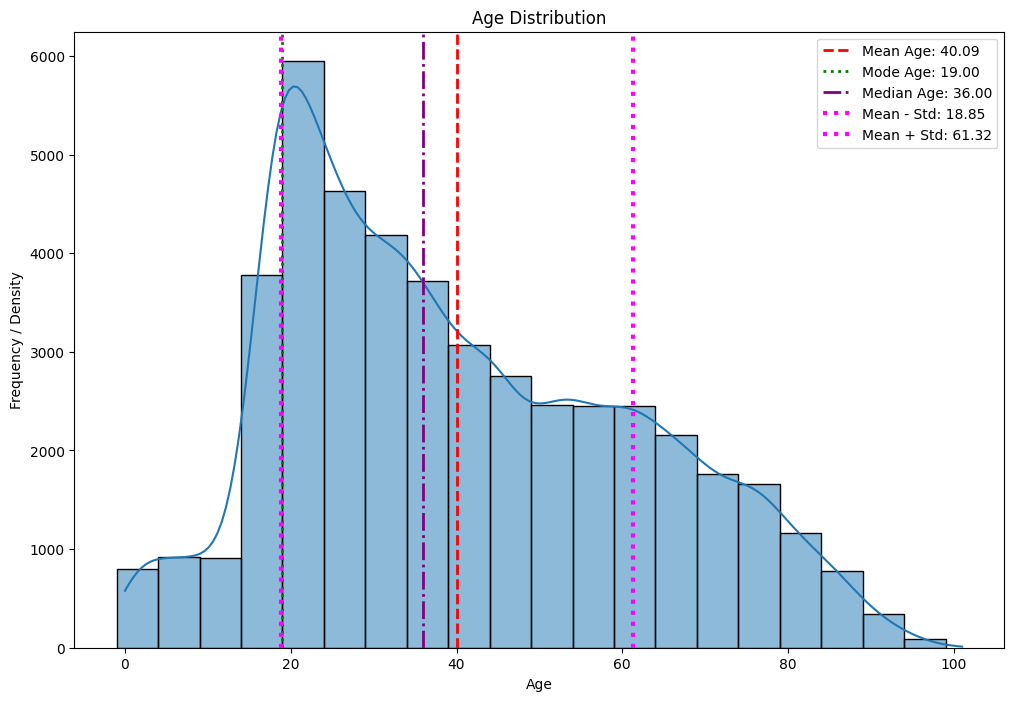

,AGE
count,46027.000000
mean,40.086514
std,21.232070
min,0.000000
25%,23.000000
50%,36.000000
75%,56.000000
max,101.000000


In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

age = df_far_person_v1['AGE']

# Create a histogram
plt.figure(figsize=(12, 8))
sns.histplot(age, bins=range(-1,101,5), kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency / Density')

# Calculate the mean age
mean_age = age.mean()

# Plot a vertical line for the mean
plt.axvline(mean_age, color='red', linestyle='dashed', linewidth=2, label=f'Mean Age: {mean_age:.2f}')

# Calculate the mode age (can be multiple modes)
mode_age = age.mode().values

# Plot vertical lines for each mode
for m_age in mode_age:
    plt.axvline(m_age, color='green', linestyle='dotted', linewidth=2, label=f'Mode Age: {m_age:.2f}')

# Calculate the median age
median_age = age.median()

# Plot a vertical line for the median
plt.axvline(median_age, color='purple', linestyle='dashdot', linewidth=2, label=f'Median Age: {median_age:.2f}')

# Calculate standard deviation
std_dev_age = age.std()

# Plot lines for mean +/- standard deviation
plt.axvline(mean_age - std_dev_age, color='magenta', linestyle=':', linewidth=3, label=f'Mean - Std: {(mean_age - std_dev_age):.2f}')
plt.axvline(mean_age + std_dev_age, color='magenta', linestyle=':', linewidth=3, label=f'Mean + Std: {(mean_age + std_dev_age):.2f}')

plt.legend()

plt.show()
age.describe()

In [203]:
df_children_group= df_far_person_v1.copy()
df_children_grp= df_children_group[
    (df_children_group['AGE'] >= 0) &
    (df_children_group['AGE'] <= 17)
    ]
df_children_grp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5167 entries, 10 to 46017
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   STATE         5167 non-null   int64 
 1   STATENAME     5167 non-null   object
 2   ST_CASE       5167 non-null   int64 
 3   VEH_NO        5167 non-null   int64 
 4   PER_NO        5167 non-null   int64 
 5   AGE           5167 non-null   int64 
 6   AGENAME       5167 non-null   object
 7   SEX           5167 non-null   int64 
 8   SEXNAME       5167 non-null   object
 9   PER_TYP       5167 non-null   int64 
 10  PER_TYPNAME   5167 non-null   object
 11  INJ_SEV       5167 non-null   int64 
 12  INJ_SEVNAME   5167 non-null   object
 13  REST_USE      5167 non-null   int64 
 14  REST_USENAME  5167 non-null   object
 15  SEAT_POS      5167 non-null   int64 
 16  SEAT_POSNAME  5167 non-null   object
 17  BODY_TYP      5167 non-null   int64 
 18  BODY_TYPNAME  5167 non-null   object
 19  RUR_URB  

In [204]:
df_children_grp[['AGE','AGENAME']].value_counts(), df_children_grp.value_counts().sum()

(AGE  AGENAME           
 17   17 Years              1040
 16   16 Years               797
 15   15 Years               408
 14   14 Years               294
 1    1 Year                 216
 0    Less than One Year     210
 13   13 Years               206
 8    8 Years                202
 2    2 Years                188
 11   11 Years               187
 7    7 Years                186
 3    3 Years                180
 4    4 Years                180
 6    6 Years                179
 5    5 Years                176
 9    9 Years                173
 10   10 Years               173
 12   12 Years               172
 Name: count, dtype: int64,
 np.int64(5167))

11.124056512483065
[17]
13.0
5.6772034267449545


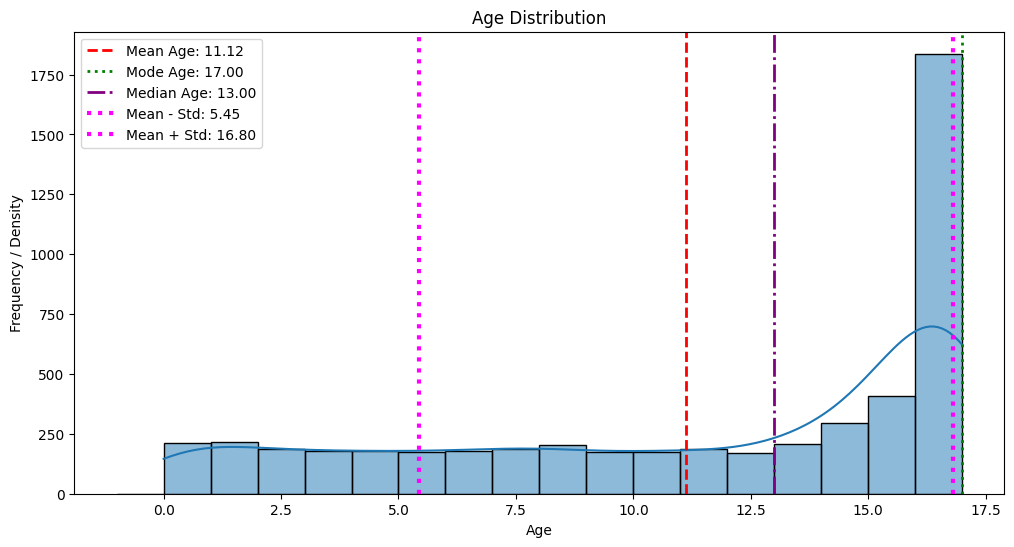

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns

age_child = df_children_grp['AGE']

# Create a histogram
plt.figure(figsize=(12, 6))
sns.histplot(age_child, bins=range(-1,18,1), kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency / Density')

# Calculate the mean age_child
mean_age_child = age_child.mean()
print(mean_age_child)

# Plot a vertical line for the mean
plt.axvline(mean_age_child, color='red', linestyle='dashed', linewidth=2, label=f'Mean Age: {mean_age_child:.2f}')

# Calculate the mode age_child (can be multiple modes)
mode_age_child = age_child.mode().values
print(mode_age_child)

# Plot vertical lines for each mode
for m_age in mode_age_child:
    plt.axvline(m_age, color='green', linestyle='dotted', linewidth=2, label=f'Mode Age: {m_age:.2f}')

# Calculate the median age_child
median_age_child = age_child.median()
print(median_age_child)

# Plot a vertical line for the median
plt.axvline(median_age_child, color='purple', linestyle='dashdot', linewidth=2, label=f'Median Age: {median_age_child:.2f}')

# Calculate standard deviation
std_dev_age_child = age_child.std()
print(std_dev_age_child)

# Plot lines for mean +/- standard deviation
plt.axvline(mean_age_child - std_dev_age_child, color='magenta', linestyle=':', linewidth=3, label=f'Mean - Std: {(mean_age_child - std_dev_age_child):.2f}')
plt.axvline(mean_age_child + std_dev_age_child, color='magenta', linestyle=':', linewidth=3, label=f'Mean + Std: {(mean_age_child + std_dev_age_child):.2f}')

plt.legend()

plt.show()

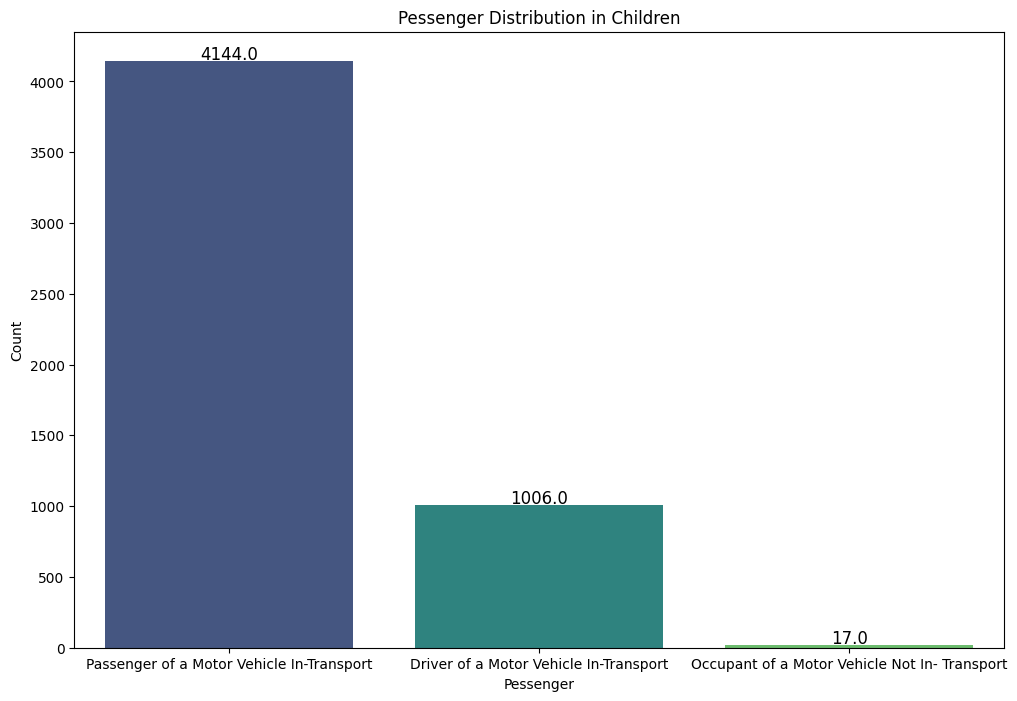

In [207]:
import matplotlib.pyplot as plt
import seaborn as sns

child_per_typ = df_children_grp['PER_TYPNAME']

# Create a bar chart for gender distribution
plt.figure(figsize=(12, 8))
ax = sns.countplot(x=child_per_typ, hue=child_per_typ, palette='viridis', legend=False)

plt.title('Pessenger Distribution in Children')
plt.xlabel('Pessenger')
plt.ylabel('Count')

# Add numerical annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()


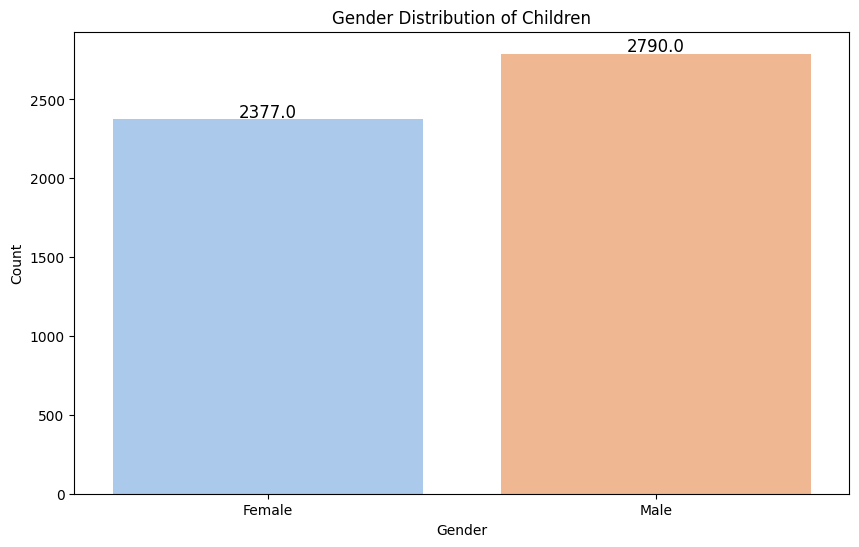

In [208]:
import matplotlib.pyplot as plt
import seaborn as sns

child_gender = df_children_grp['SEXNAME']

# Create a bar chart for gender distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=child_gender, hue=child_gender, palette='pastel', legend=False)

plt.title('Gender Distribution of Children')
plt.xlabel('Gender')
plt.ylabel('Count')

# Add numerical annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

In [209]:
df_tmp = df_children_grp[['INJ_SEV','INJ_SEVNAME']].copy()
df_tmp[['INJ_SEV','INJ_SEVNAME']].value_counts()

,,count
INJ_SEV,INJ_SEVNAME,
0,No Apparent Injury (O),1639
4,Fatal Injury (K),1045
2,Suspected Minor Injury (B),936
3,Suspected Serious Injury (A),923
1,Possible Injury (C),610
5,"Injured, Severity Unknown",14


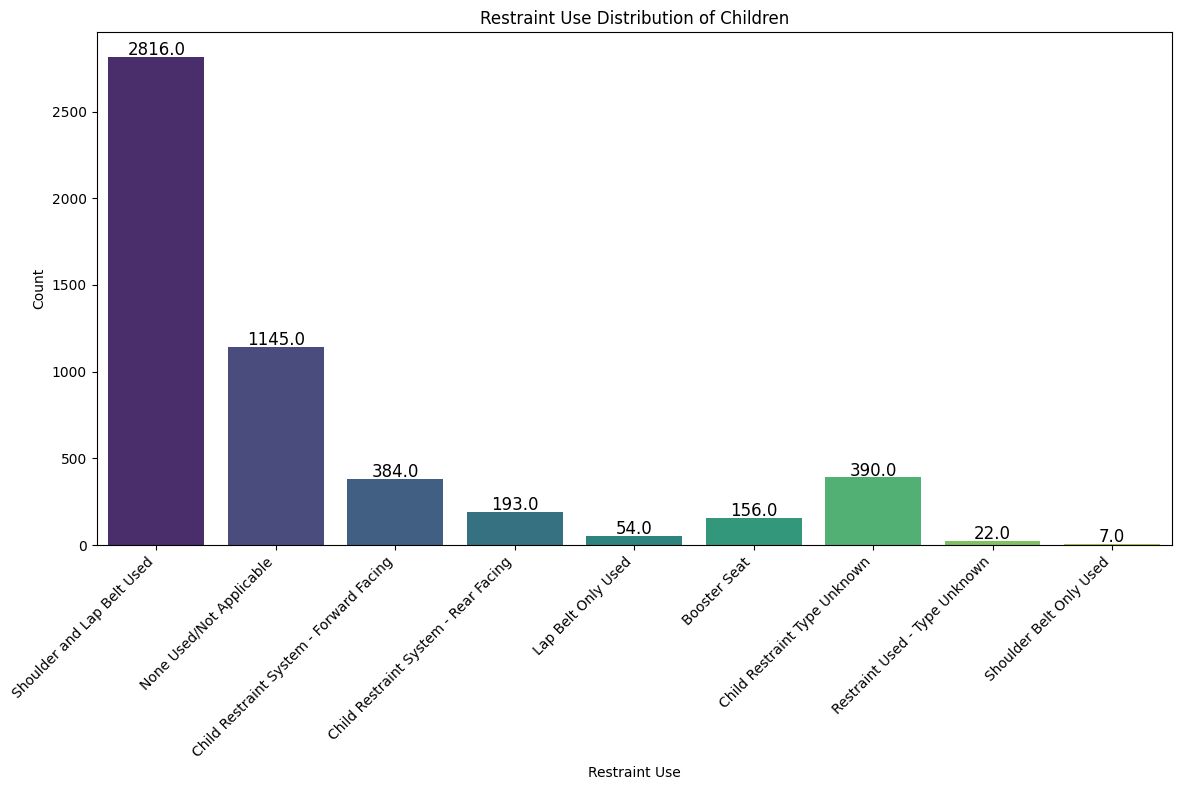

In [210]:
import matplotlib.pyplot as plt
import seaborn as sns

child_rest_use = df_children_grp['REST_USENAME']

# Create a bar chart for restraint use distribution
plt.figure(figsize=(12, 8))
ax = sns.countplot(x=child_rest_use, hue=child_rest_use, palette='viridis', legend=False)

plt.title('Restraint Use Distribution of Children')
plt.xlabel('Restraint Use')
plt.ylabel('Count')

# Add numerical annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

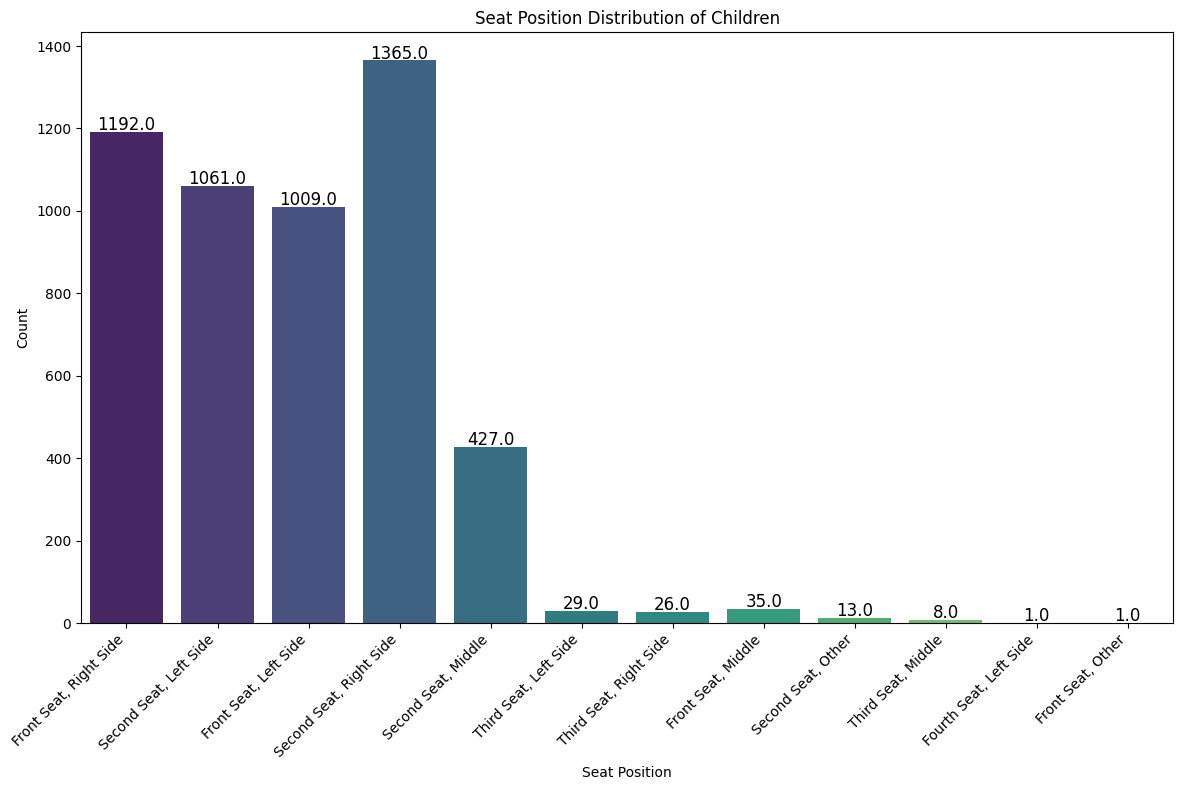

In [211]:
import matplotlib.pyplot as plt
import seaborn as sns

child_seat_pos = df_children_grp['SEAT_POSNAME']

# Create a bar chart for seat position distribution
plt.figure(figsize=(12, 8))
ax = sns.countplot(x=child_seat_pos, hue=child_seat_pos, palette='viridis', legend=False)

plt.title('Seat Position Distribution of Children')
plt.xlabel('Seat Position')
plt.ylabel('Count')

# Add numerical annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

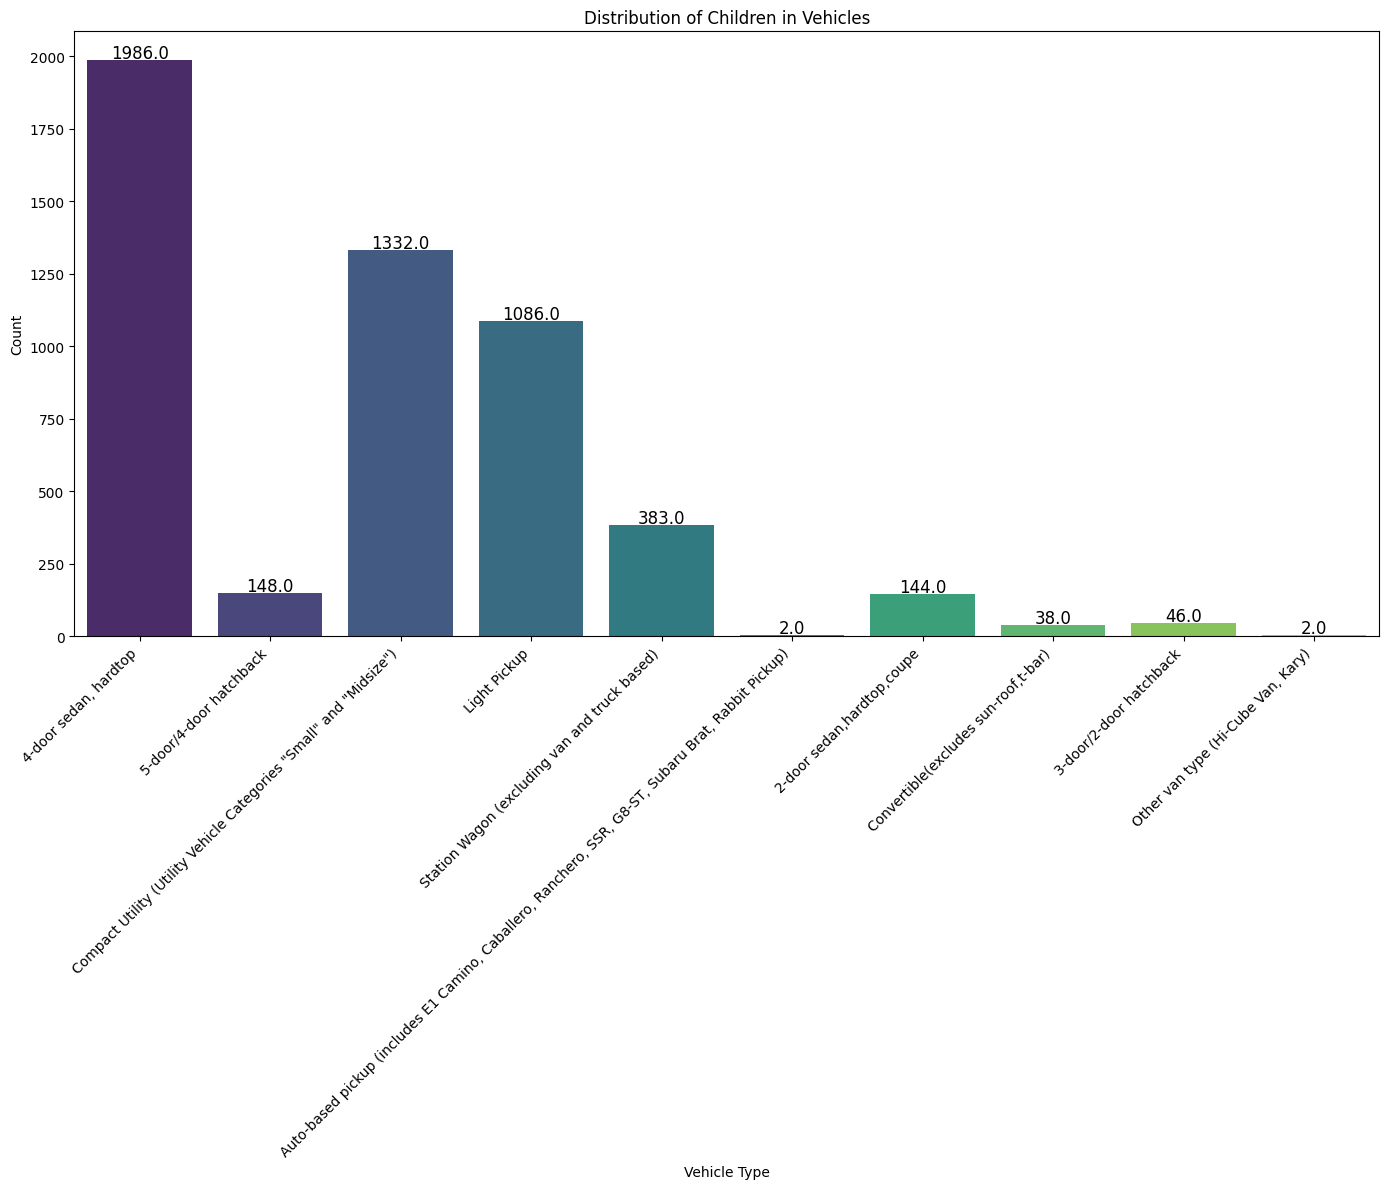

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns

child_veh_typ = df_children_grp['BODY_TYPNAME']

# Create a bar chart for vehicle type distribution
plt.figure(figsize=(14, 12))
ax = sns.countplot(x=child_veh_typ, hue=child_veh_typ, palette='viridis', legend=False)

plt.title('Distribution of Children in Vehicles')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')

# Add numerical annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

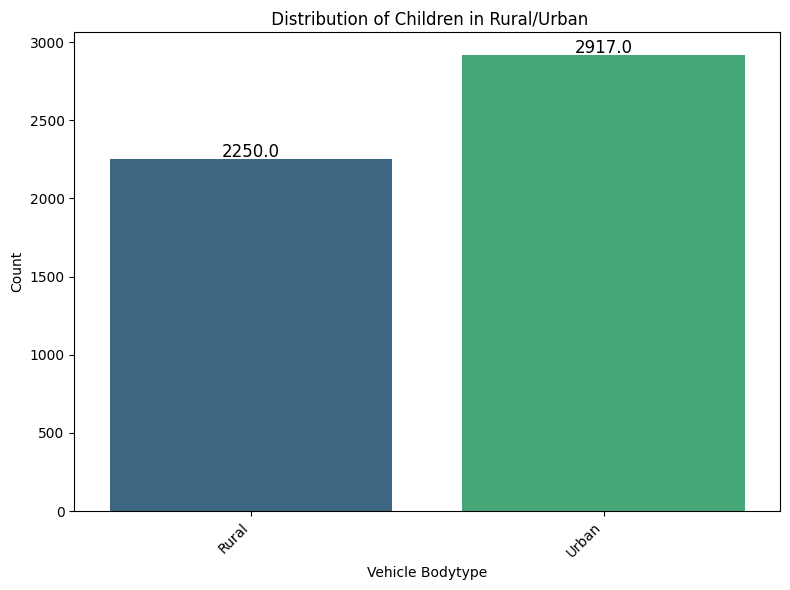

In [213]:
import matplotlib.pyplot as plt
import seaborn as sns

child_res_typ = df_children_grp['RUR_URBNAME']

# Create a bar chart for vehicle type distribution
plt.figure(figsize=(8, 6))
ax = sns.countplot(x=child_res_typ, hue=child_res_typ, palette='viridis', legend=False)

plt.title(' Distribution of Children in Rural/Urban')
plt.xlabel('Vehicle Bodytype')
plt.ylabel('Count')

# Add numerical annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

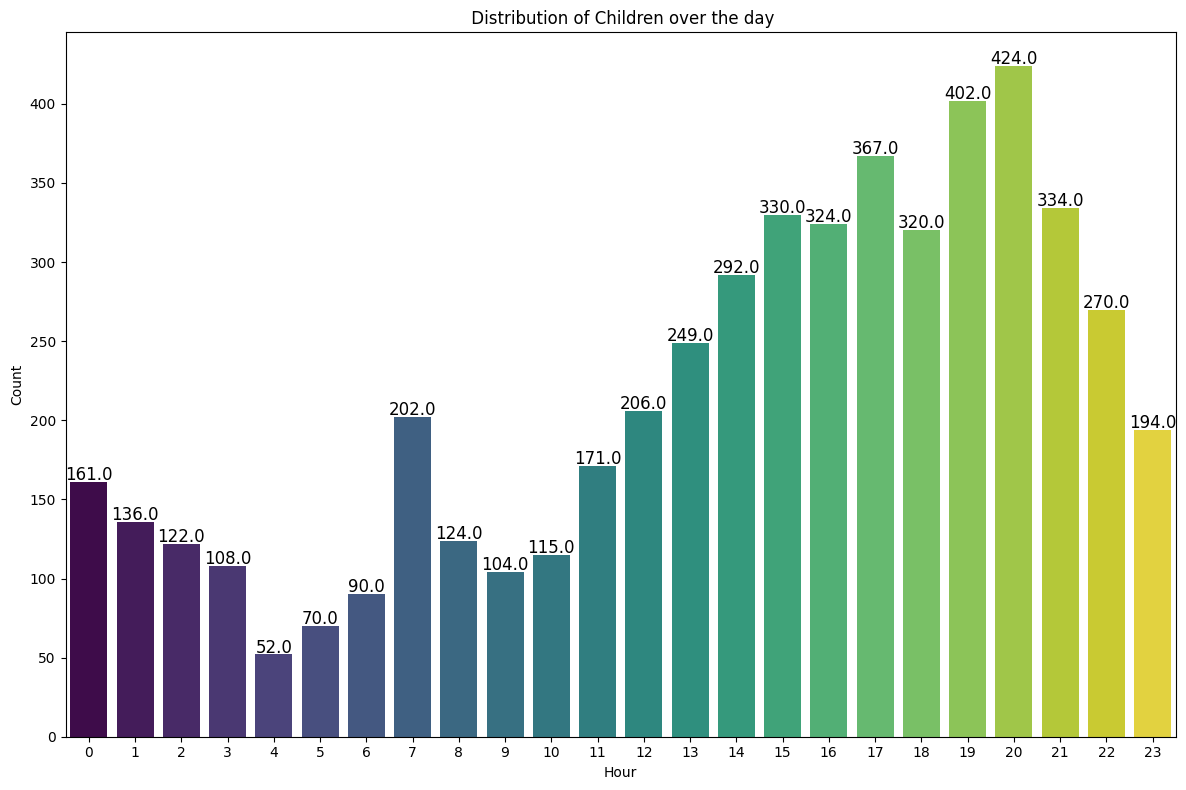

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns

child_hour = df_children_grp['HOUR']

# Create a bar chart for vehicle type distribution
plt.figure(figsize=(12, 8))
ax = sns.countplot(x=child_hour, hue=child_hour, palette='viridis', legend=False)

plt.title(' Distribution of Children over the day')
plt.xlabel('Hour')
plt.ylabel('Count')

# Add numerical annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

#plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

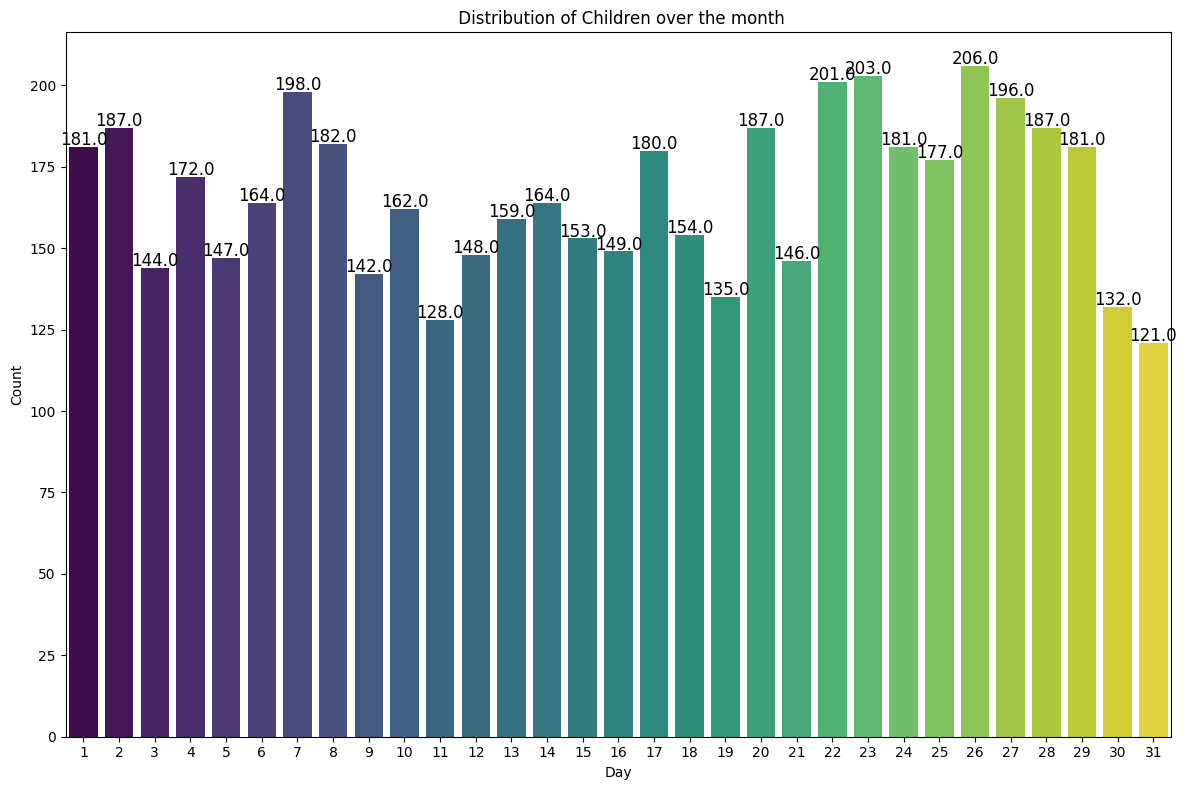

In [215]:
import matplotlib.pyplot as plt
import seaborn as sns

child_day = df_children_grp['DAY']

# Create a bar chart for vehicle type distribution
plt.figure(figsize=(12, 8))
ax = sns.countplot(x=child_day, hue=child_day, palette='viridis', legend=False)

plt.title(' Distribution of Children over the month')
plt.xlabel('Day')
plt.ylabel('Count')

# Add numerical annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

#plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

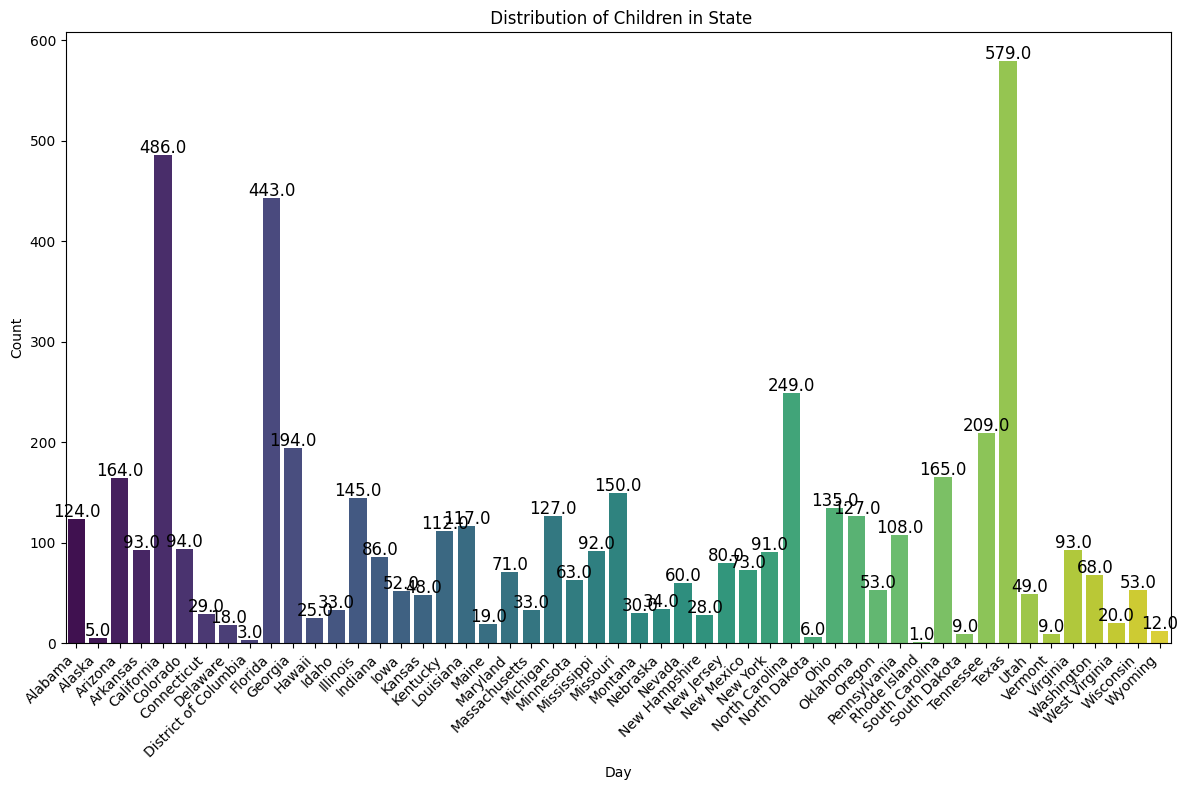

In [216]:
import matplotlib.pyplot as plt
import seaborn as sns

child_in_state = df_children_grp['STATENAME']

# Create a bar chart for vehicle type distribution
plt.figure(figsize=(12, 8))
ax = sns.countplot(x=child_in_state, hue=child_in_state, palette='viridis', legend=False)

plt.title(' Distribution of Children in State')
plt.xlabel('Day')
plt.ylabel('Count')

# Add numerical annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

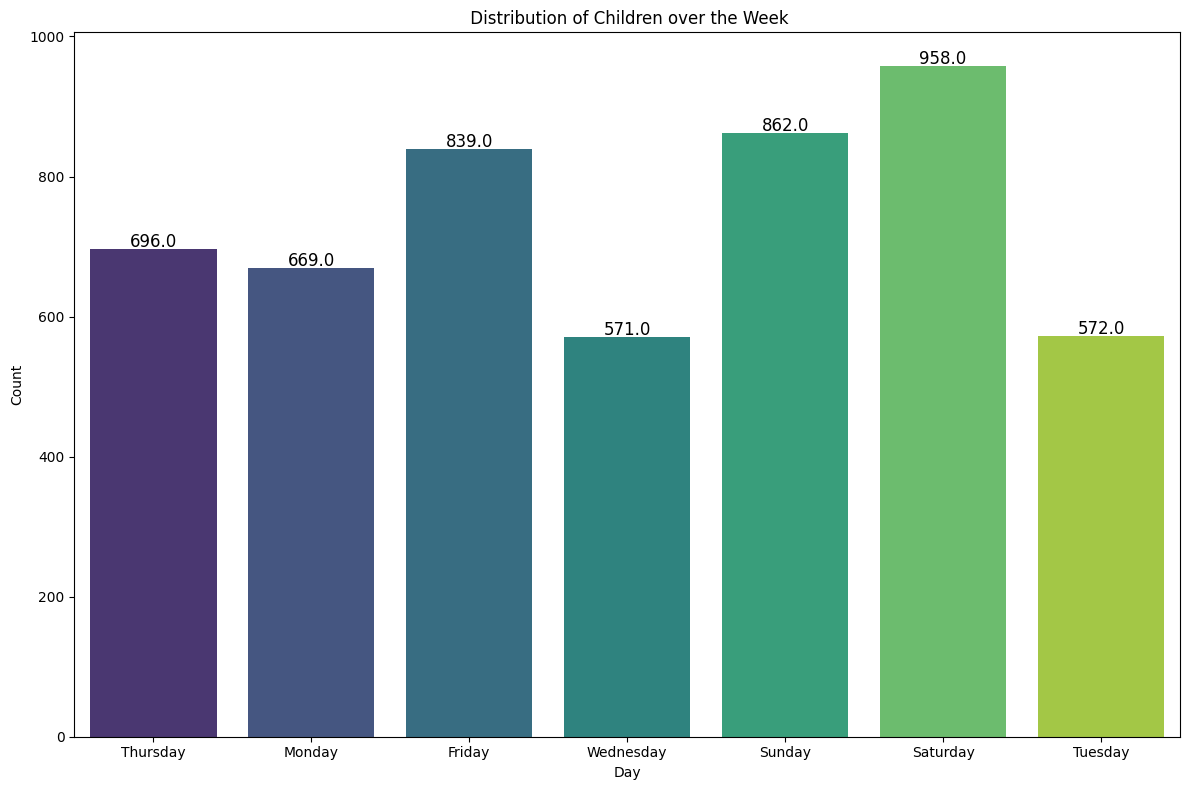

In [217]:
import matplotlib.pyplot as plt
import seaborn as sns

child_wday = df_children_grp['DAY_WEEKNAME']

# Create a bar chart for vehicle type distribution
plt.figure(figsize=(12, 8))
ax = sns.countplot(x=child_wday, hue=child_wday, palette='viridis', legend=False)

plt.title(' Distribution of Children over the Week')
plt.xlabel('Day')
plt.ylabel('Count')

# Add numerical annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

#plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# FATALITY ANALYSIS

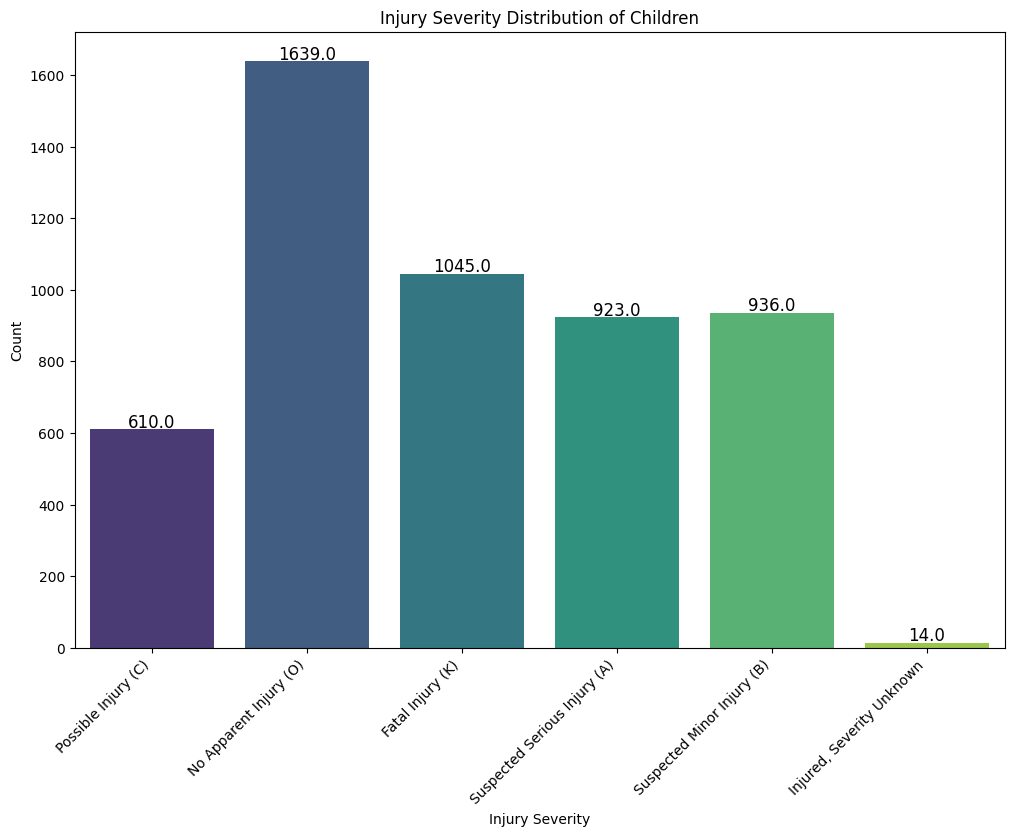

In [218]:
import matplotlib.pyplot as plt
import seaborn as sns

child_injry = df_children_grp['INJ_SEVNAME']

# Create a bar chart for injury severity distribution
plt.figure(figsize=(12, 8))
ax = sns.countplot(x=child_injry, hue=child_injry, palette='viridis', legend=False)

plt.title('Injury Severity Distribution of Children')
plt.xlabel('Injury Severity')
plt.ylabel('Count')

# Add numerical annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.show()

In [219]:
df_children_grp = df_children_grp.copy()
df_children_grp['FATALITY'] = np.where(df_children_grp['INJ_SEV'].isin([4,6]),'FATAL','NON-FATAL')
df_children_grp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5167 entries, 10 to 46017
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   STATE         5167 non-null   int64 
 1   STATENAME     5167 non-null   object
 2   ST_CASE       5167 non-null   int64 
 3   VEH_NO        5167 non-null   int64 
 4   PER_NO        5167 non-null   int64 
 5   AGE           5167 non-null   int64 
 6   AGENAME       5167 non-null   object
 7   SEX           5167 non-null   int64 
 8   SEXNAME       5167 non-null   object
 9   PER_TYP       5167 non-null   int64 
 10  PER_TYPNAME   5167 non-null   object
 11  INJ_SEV       5167 non-null   int64 
 12  INJ_SEVNAME   5167 non-null   object
 13  REST_USE      5167 non-null   int64 
 14  REST_USENAME  5167 non-null   object
 15  SEAT_POS      5167 non-null   int64 
 16  SEAT_POSNAME  5167 non-null   object
 17  BODY_TYP      5167 non-null   int64 
 18  BODY_TYPNAME  5167 non-null   object
 19  RUR_URB  

In [220]:
df_children_grp['FATALITY'].value_counts()

,count
FATALITY,
NON-FATAL,4122
FATAL,1045


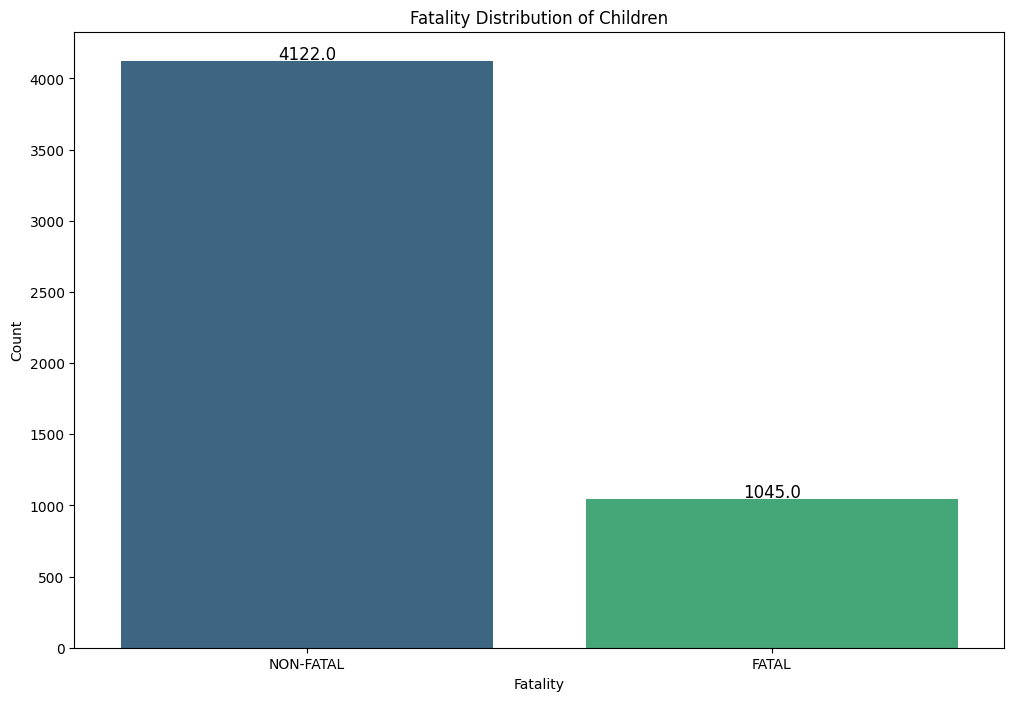

In [221]:
import matplotlib.pyplot as plt
import seaborn as sns

child_fatality = df_children_grp['FATALITY']

# Create a bar chart for injury severity distribution
plt.figure(figsize=(12, 8))
ax = sns.countplot(x=child_fatality, hue=child_fatality, palette='viridis', legend=False)

plt.title('Fatality Distribution of Children')
plt.xlabel('Fatality')
plt.ylabel('Count')

# Add numerical annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

#plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.show()